## **I. import package**

In [60]:
import pandas, numpy

### 1. integrasikan Gdrive untuk menyimpan tabel kohort

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. import data ke dataframe

In [62]:
import requests
import zipfile
import io
import pandas as pd # Ensure pandas is imported

# URL of the zip file containing the dataset
zip_file_url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

# Download the zip file
print("Downloading dataset...")
response = requests.get(zip_file_url)
response.raise_for_status() # Raise an exception for HTTP errors
print("Download complete. Extracting file...")

# Use BytesIO to handle the zip file content in memory
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Find the Excel file within the zip archive
    excel_file_name = None
    for f_name in z.namelist():
        if f_name.endswith('.xlsx'):
            excel_file_name = f_name
            break

    if excel_file_name:
        # Read the Excel file directly from the zip archive into a pandas DataFrame
        with z.open(excel_file_name) as excel_file:
            df = pd.read_excel(excel_file)
        print(f"Data loaded successfully into DataFrame 'df' from '{excel_file_name}'.")

    else:
        print("Error: No .xlsx file found in the zip archive.")
        print(f"Files found in zip: {z.namelist()}")

Download complete. Extracting file...
Data loaded successfully into DataFrame 'df' from 'Online Retail.xlsx'.


In [63]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### 3. data cleansing

In [65]:
# 1. Mengkonversi kolom InvoiceDate menjadi datetime (sudah datetime64[ns], tapi memastikan)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Menghapus semua baris tanpa CustomerID
df.dropna(subset=['CustomerID'], inplace=True)

# 3. Menghapus semua baris tanpa Description
df.dropna(subset=['Description'], inplace=True)

# 4. Mengubah nilai quantity yang negatif menjadi positif
df['Quantity'] = df['Quantity'].abs()

# 5. Menghapus baris dengan price yang bernilai negatif
df = df[df['UnitPrice'] >= 0]

# 6. Mengkonversi CustomerID menjadi string
df['CustomerID'] = df['CustomerID'].astype(str)

print("Data cleansing complete. Displaying the first 5 rows of the cleaned DataFrame:")

Data cleansing complete. Displaying the first 5 rows of the cleaned DataFrame:


In [66]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB


### 4. data setting

In [68]:
# 1. Membuat kolom year_month
df['year_month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
print("Kolom 'year_month' berhasil dibuat.")

# 2. Membuat kolom order_status
df['order_status'] = df['InvoiceNo'].apply(lambda x: 'cancelled' if str(x).startswith('C') else 'delivered')
print("Kolom 'order_status' berhasil dibuat.")

# 3. Membuat nilai amount
df['Amount'] = df['Quantity'] * df['UnitPrice']
print("Kolom 'amount' berhasil dibuat.")

# 4. Menghapus outlier menggunakan metode IQR
from scipy import stats
import numpy as np
df = df[(np.abs(stats.zscore(df[['Quantity','Amount']]))<3).all(axis=1)]
df = df.reset_index(drop=True)
df
print(f"Menghapus {removed_rows} outlier dari kolom 'Amount'.")

print("\nData setting dan cleansing tambahan selesai. Menampilkan 5 baris pertama DataFrame:")

Kolom 'year_month' berhasil dibuat.
Kolom 'order_status' berhasil dibuat.
Kolom 'amount' berhasil dibuat.
Menghapus 32138 outlier dari kolom 'Amount'.

Data setting dan cleansing tambahan selesai. Menampilkan 5 baris pertama DataFrame:


In [69]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year_month,order_status,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,delivered,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,delivered,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12,delivered,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,delivered,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,delivered,20.34


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406460 entries, 0 to 406459
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     406460 non-null  object        
 1   StockCode     406460 non-null  object        
 2   Description   406460 non-null  object        
 3   Quantity      406460 non-null  int64         
 4   InvoiceDate   406460 non-null  datetime64[ns]
 5   UnitPrice     406460 non-null  float64       
 6   CustomerID    406460 non-null  object        
 7   Country       406460 non-null  object        
 8   year_month    406460 non-null  object        
 9   order_status  406460 non-null  object        
 10  Amount        406460 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 34.1+ MB


In [71]:
import numpy as np
from scipy import stats

df = df[(np.abs(stats.zscore(df[['Quantity','Amount']]))<3).all(axis=1)]
df = df.reset_index(drop=True)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,year_month,order_status,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,delivered,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,delivered,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12,delivered,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,delivered,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,delivered,20.34
...,...,...,...,...,...,...,...,...,...,...,...
397184,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011-12,delivered,10.20
397185,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12,delivered,12.60
397186,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12,delivered,16.60
397187,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12,delivered,16.60


In [72]:
df.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)
print("DataFrame 'df' berhasil disimpan sebagai 'cleaned_data.csv' di Google Drive.")

DataFrame 'df' berhasil disimpan sebagai 'cleaned_data.csv' di Google Drive.


## **II. membuat tabel kohort**

### 1. Agregat data transaksi ke bentuk summary total transaksi/order setiap pengguna setiap bulan

In [74]:
# Agregat data untuk mendapatkan total transaksi dan jumlah order per CustomerID per bulan
cohort_data = df.groupby(['CustomerID', 'year_month']).agg(
    total_amount=('Amount', 'sum'),
    total_orders=('InvoiceNo', 'nunique')
).reset_index()

print("Summary of total transactions/orders per user per month:")

Summary of total transactions/orders per user per month:


In [75]:
cohort_data.head()

,CustomerID,year_month,total_amount,total_orders
0,12347.0,2010-12,711.79,1
1,12347.0,2011-01,475.39,1
2,12347.0,2011-04,386.65,1
3,12347.0,2011-06,382.52,1
4,12347.0,2011-08,584.91,1


### 2. Buat kolom sebagai cohort dari pengguna, misal cohort bulan pertama kali bertransaksi

In [76]:
cohort_data['InvoiceDate'] = pd.to_datetime(cohort_data['year_month'])
first_purchase_month = cohort_data.groupby('CustomerID')['InvoiceDate'].min()

cohort_data['cohort_month'] = cohort_data['CustomerID'].map(first_purchase_month).dt.to_period('M').astype(str)

print("Kolom 'cohort_month' berhasil dibuat.")
print("Displaying the first 5 rows with the new cohort_month column:")

Kolom 'cohort_month' berhasil dibuat.
Displaying the first 5 rows with the new cohort_month column:


In [ ]:
cohort_data.head()

### 3. Hitung jarak bulan antara bulan transaksi dengan bulan pertama kali transaksi dan jumlahkan dengan 1 agar jarak bulan 0 menjadi 1 yang berarti bulan pertama, dst.

In [77]:
cohort_data['year_month_period'] = cohort_data['year_month'].apply(lambda x: pd.Period(x, 'M'))
cohort_data['cohort_month_period'] = cohort_data['cohort_month'].apply(lambda x: pd.Period(x, 'M'))

cohort_data['month_period'] = (cohort_data['year_month_period'] - cohort_data['cohort_month_period']).apply(lambda x: x.n) + 1

print("Kolom 'month_period' berhasil dibuat.")
print("Displaying the first 10 rows with the new month_period column:")

Kolom 'month_period' berhasil dibuat.
Displaying the first 10 rows with the new month_period column:


In [78]:
cohort_data.head(10)

,CustomerID,year_month,total_amount,total_orders,InvoiceDate,cohort_month,year_month_period,cohort_month_period,month_period
0,12347.0,2010-12,711.79,1,2010-12-01,2010-12,2010-12,2010-12,1
1,12347.0,2011-01,475.39,1,2011-01-01,2010-12,2011-01,2010-12,2
2,12347.0,2011-04,386.65,1,2011-04-01,2010-12,2011-04,2010-12,5
3,12347.0,2011-06,382.52,1,2011-06-01,2010-12,2011-06,2010-12,7
4,12347.0,2011-08,584.91,1,2011-08-01,2010-12,2011-08,2010-12,9
5,12347.0,2011-10,1294.32,1,2011-10-01,2010-12,2011-10,2010-12,11
6,12347.0,2011-12,224.82,1,2011-12-01,2010-12,2011-12,2010-12,13
7,12348.0,2010-12,367.68,1,2010-12-01,2010-12,2010-12,2010-12,1
8,12348.0,2011-01,60.40,1,2011-01-01,2010-12,2011-01,2010-12,2
9,12348.0,2011-04,367.00,1,2011-04-01,2010-12,2011-04,2010-12,5


In [79]:
cohort_data.to_csv('/content/drive/MyDrive/cohort_data.csv', index=False)
print("DataFrame 'cohort_data' berhasil disimpan sebagai 'cohort_data.csv' di Google Drive.")

DataFrame 'cohort_data' berhasil disimpan sebagai 'cohort_data.csv' di Google Drive.


### 4.1 Hitung banyaknya pengguna di masing-masing cohort (pengguna yang pertama kali transaksi di bulan tersebut).

In [80]:
cohort_sizes = cohort_data.groupby('cohort_month')['CustomerID'].nunique()
print("Jumlah pengguna di masing-masing cohort:")
print(cohort_sizes)

Jumlah pengguna di masing-masing cohort:
cohort_month
2010-12    919
2011-01    410
2011-02    374
2011-03    437
2011-04    293
2011-05    271
2011-06    231
2011-07    192
2011-08    165
2011-09    294
2011-10    352
2011-11    317
2011-12     39
Name: CustomerID, dtype: int64


### 4.2 bagi semua nilai di tabel pivot tadi dengan nilai tersebut sebagai retention rate.

In [81]:
cohort_counts = cohort_data.pivot_table(index='cohort_month', columns='month_period', values='CustomerID', aggfunc='nunique')

# Divide all values in the cohort_counts table by the cohort_sizes (number of customers in month 1)
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0)

print("Retention Matrix:")

Retention Matrix:


In [82]:
retention_matrix

month_period,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,
2010-12,1.0,0.379761,0.327530,0.378672,0.355822,0.397171,0.379761,0.344940,0.350381,0.388466,0.369967,0.499456,0.266594
2011-01,1.0,0.236585,0.290244,0.234146,0.326829,0.300000,0.260976,0.260976,0.317073,0.346341,0.368293,0.153659,NaN
2011-02,1.0,0.245989,0.205882,0.278075,0.270053,0.254011,0.248663,0.272727,0.264706,0.320856,0.093583,NaN,NaN
2011-03,1.0,0.183066,0.251716,0.221968,0.231121,0.178490,0.260870,0.237986,0.281465,0.086957,NaN,NaN,NaN
2011-04,1.0,0.228669,0.218430,0.204778,0.201365,0.245734,0.235495,0.262799,0.085324,NaN,NaN,NaN,NaN
2011-05,1.0,0.236162,0.169742,0.173432,0.221402,0.239852,0.273063,0.103321,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.212121,0.190476,0.272727,0.238095,0.329004,0.108225,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.203125,0.218750,0.244792,0.281250,0.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.242424,0.260606,0.254545,0.145455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
retention_matrix.to_excel('/content/drive/MyDrive/retention_matrix.xlsx', index=False)
print("DataFrame 'retention_matrix' berhasil disimpan sebagai 'retention_matrix.xlsx' di Google Drive.")

DataFrame 'retention_matrix' berhasil disimpan sebagai 'retention_matrix.xlsx' di Google Drive.


### 5. Tampilkan tabel pivot yang sudah berisi nilai retention rate tersebut dalam heatmap

Plot heatmap berhasil disimpan ke '/content/drive/MyDrive/retention_heatmap.png' dengan resolusi 150 DPI.


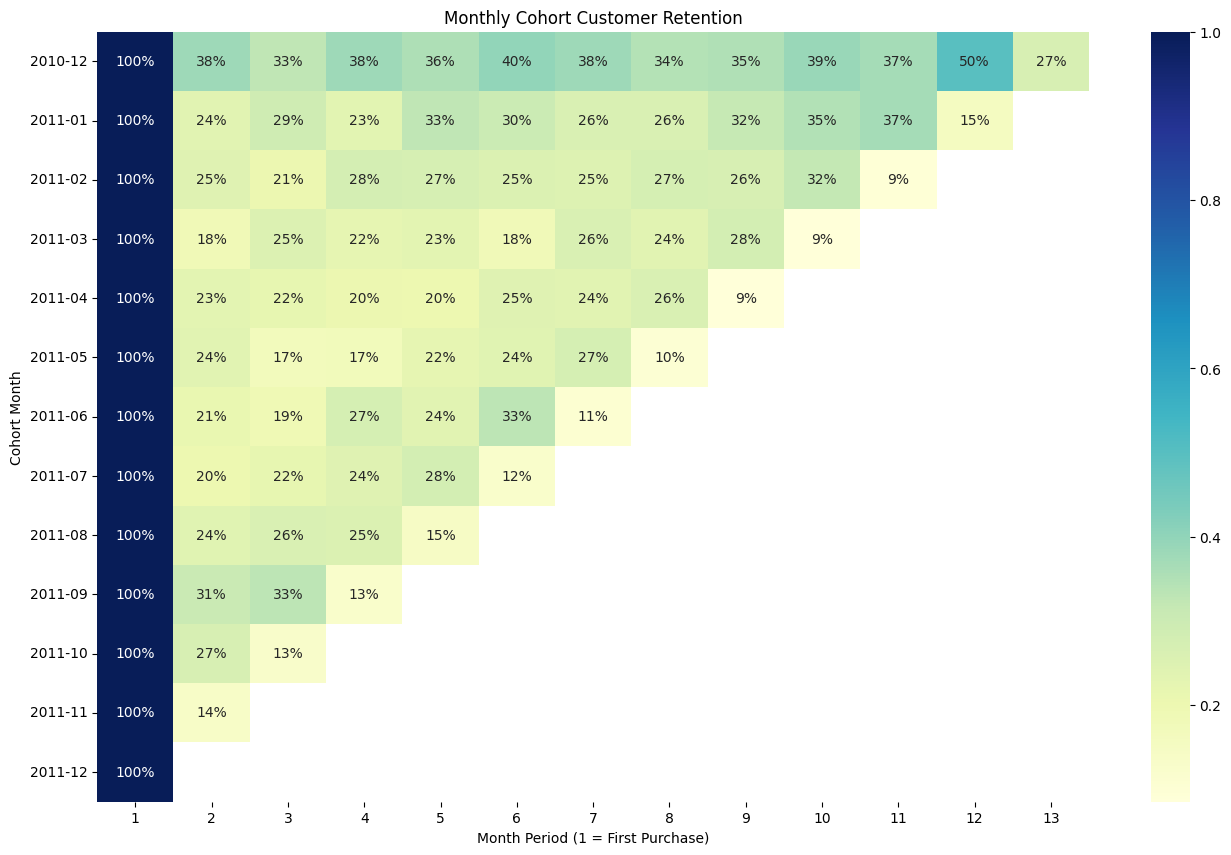

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Monthly Cohort Customer Retention')
plt.xlabel('Month Period (1 = First Purchase)')
plt.ylabel('Cohort Month')
plt.tick_params(axis='y', labelrotation=0)

# Define the file path for saving in Google Drive
save_path = '/content/drive/MyDrive/retention_heatmap.png'

# Save the figure with the specified resolution
plt.gcf().savefig(save_path, dpi=150, bbox_inches='tight')

print(f"Plot heatmap berhasil disimpan ke '{save_path}' dengan resolusi 150 DPI.")
plt.show()